The goal of this notebook is to use historical stock market data to make a simple prediction about the future. Specifically, the model tries to answer the following question: given what we know about a stock today, will its price be higher or lower tomorrow?

This notebook builds a machine-learning model that attempts to predict whether a stock’s closing price will increase on the next trading day. The problem is framed as a binary classification task, where a value of 1 indicates that tomorrow’s closing price is higher than today’s, and 0 indicates otherwise. The model is trained on historical OHLCV data across many tickers and evaluated using a time-aware train–test split to avoid look-ahead bias. A Random Forest classifier is used as a fast and robust baseline model, and performance is evaluated using accuracy, ROC–AUC, and several diagnostic plots.

## Imports and dependencies
From scikit-learn, a RandomForestClassifier is imported to serve as the predictive model. A RobustScaler is used for feature scaling, as it is less sensitive to outliers than standard normalization methods. Several evaluation metrics are also imported, including accuracy, ROC–AUC, confusion matrix computation, and ROC curve generation, all of which are used to assess different aspects of model performance.

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, roc_curve
)

## Setting up the model
Before loading any data, several settings are defined. These settings control where the data is stored, how much data is used, and how the model behaves. For example, limits are placed on how many rows of data are used so that the model can be trained quickly on a standard computer.

A fixed random seed is also chosen. Setting a seed ensures that results can be reproduced. This means that running the notebook again will give the same results, which is important when learning or debugging.

In [ ]:
DATA_DIR = Path("../data/raw/Stocks")
FOCUS_TICKERS = ["amzn","msft","nke","tsco"]

MAX_ROWS_TOTAL = 120_000
MAX_ROWS_PER_TICKER = 800
N_TREES = 100
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## Loading the stock data
The unique stock's data is stored in a different file. Each file contains daily information such as opening price, highest price, lowest price, closing price, and trading volume.

THe files are loaded one by one and combined into a single table. A new column is added to identify which stock each row belongs to. Dates are converted into a proper date format so that the data can be sorted and compared correctly.

Rows that are missing important values are removed. This is necessary because machine-learning models cannot work with missing numbers. The data is then sorted so that each stock’s history appears in the correct time order.

In [ ]:
dfs = []
for f in DATA_DIR.glob("*.txt"):
    try:
        df = pd.read_csv(f)
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Ticker"] = f.stem.replace(".us","")
        dfs.append(df)
    except:
        continue

df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=["Date","Open","High","Low","Close","Volume"])
df = df.sort_values(["Ticker","Date"])

## Defining the model's prediction aim
To train the model, we tell it what the correct answers are for past data. In this case, the correct answer is whether the stock price went up the next day.

For each stock, the closing price of the following day is aligned with the current day. If tomorrow’s closing price is higher than today’s, the target value is set to 1. Otherwise, it is set to 0.

This step is done separately for each stock so that prices from different stocks are never mixed together. This ensures that the model learns meaningful patterns rather than random noise.

In [ ]:
df["NextClose"] = df.groupby("Ticker")["Close"].shift(-1)
df["Target"] = (df["NextClose"] > df["Close"]).astype(int)

## Creating learnable features
Several simple features are created. One feature measures how much the price changed during the day. Another measures how large the price range was between the highest and lowest prices. A third feature measures how trading volume changed compared to the previous day.

Additional features describe short-term trends. These include how much the price has changed over the last few days and how the current price compares to its recent average. These features help the model detect momentum and trend-related behavior.

Only information that would have been available at the end of the current day is used. This is important because the model should not be allowed to “see the future” when making predictions.

In [ ]:
df["ret"] = (df["Close"] - df["Open"]) / df["Open"]
df["range"] = (df["High"] - df["Low"]) / df["Open"]
df["vol_chg"] = df.groupby("Ticker")["Volume"].pct_change()

for w in [5,10]:
    df[f"ret_{w}"] = df.groupby("Ticker")["Close"].pct_change(w)
    df[f"ma_ratio_{w}"] = (
        df["Close"] /
        (df.groupby("Ticker")["Close"]
           .transform(lambda s: s.rolling(w,1).mean()) + 1e-6)
    )

FEATURES = ["ret","range","vol_chg","ret_5","ret_10","ma_ratio_5","ma_ratio_10"]

## Handling missing and invalid data
Some features cannot be calculated for the first few days of a stock’s history because there is not enough past data. These cases result in missing values. There can also be invalid values caused by division by zero or other numerical issues.

To fix this, invalid values are replaced with missing values. Then, missing values are filled using nearby values from the same stock’s history. This keeps each stock’s data consistent over time.

Any rows that still contain missing values after this process are removed. This ensures that the model only receives complete and valid data.

In [ ]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df = df.groupby("Ticker",group_keys=False).apply(lambda g: g.ffill().bfill())
df = df.dropna(subset=FEATURES+["Target"])

/tmp/ipykernel_165766/1300491184.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker",group_keys=False).apply(lambda g: g.ffill().bfill())


## Reducing the size of the dataset
Only the most recent data points are kept for each stock. This also has the advantage of focusing the model on more recent market behavior. If the dataset is still too large, a random subset is selected.

These steps make experimentation faster while still preserving a diverse and useful dataset.

In [ ]:
df = df.groupby("Ticker",group_keys=False)\
       .apply(lambda g: g.tail(MAX_ROWS_PER_TICKER))

if len(df) > MAX_ROWS_TOTAL:
    df = df.sample(MAX_ROWS_TOTAL, random_state=RANDOM_SEED)

/tmp/ipykernel_165766/3973370358.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.tail(MAX_ROWS_PER_TICKER))


## Splitting data into training and testing sets

To check whether the model truly learns useful patterns, it must be tested on data it has never seen before. For this reason, the dataset is split into two parts: a training set and a test set.

The split is done based on time. Older data is used for training, and newer data is used for testing. This mimics how the model would be used in real life, where we train on past data and make predictions about the future.

This time-based split is crucial for financial data because randomly mixing past and future data would give misleading results.

In [ ]:
split = df["Date"].quantile(0.8)
train = df[df["Date"] <= split]
test  = df[df["Date"] >  split]

X_train, y_train = train[FEATURES].values, train["Target"].values
X_test,  y_test  = test[FEATURES].values,  test["Target"].values

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

### Training the model
A Random Forest works by building many small decision trees and combining their predictions. Each tree looks at the data in a slightly different way, and the final prediction is based on the combined opinion of all trees.

Limits are placed on how complex each tree can become. This helps prevent the model from simply memorizing the training data instead of learning general patterns.

The model is trained using the training data. Once training is complete, it produces a probability for each test example that represents how confident the model is that the price will go up the next day.

In [ ]:
model_name = "Random Forest"
model = RandomForestClassifier(
    n_estimators=N_TREES,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED
)

model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:,1]
preds = (probs >= 0.5).astype(int)

## Measuring model performance
Several evaluation methods are used to understand how good the model’s predictions are. Accuracy measures how often the model makes the correct up-or-down prediction. While easy to understand, accuracy alone can be misleading if one outcome is more common than the other.

Another metric, called ROC–AUC, measures how well the model separates upward movements from downward movements across all possible thresholds. This provides a more complete picture of model quality.

Graphs are created to make the results easier to understand. One plot compares the model’s accuracy to random guessing, which helps determine whether the model has learned anything useful at all.

Another plot shows the ROC curve, which visualizes the trade-off between correctly predicting price increases and incorrectly predicting them. A confusion matrix shows the number of correct and incorrect predictions in each category.

A histogram of predicted probabilities shows how confident the model is in its predictions. Finally, the model’s performance is evaluated separately for a few selected stocks to see whether it behaves consistently across different companies.

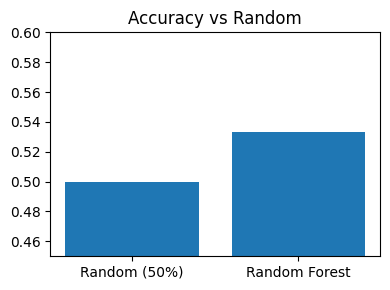

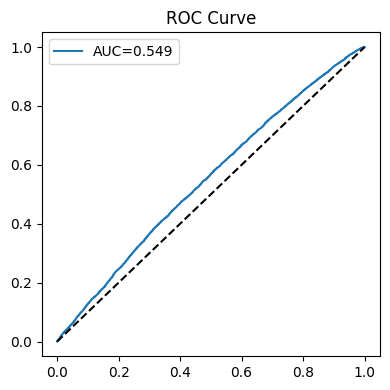

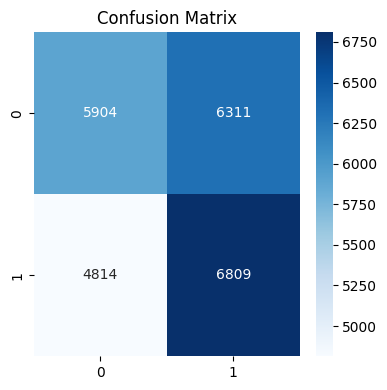

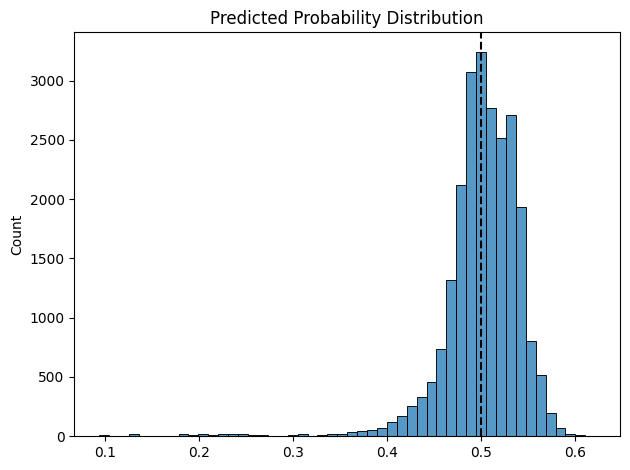

In [23]:
acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

# Accuracy vs Random
plt.figure(figsize=(4,3))
plt.bar(["Random (50%)", model_name], [0.5, acc])
plt.ylim(0.45,0.6)
plt.title("Accuracy vs Random")
plt.tight_layout()
plt.show()

# ROC
fpr,tpr,_ = roc_curve(y_test, probs)
plt.figure(figsize=(4,4))
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Probability Histogram
sns.histplot(probs, bins=50)
plt.axvline(0.5,color="k",linestyle="--")
plt.title("Predicted Probability Distribution")
plt.tight_layout()
plt.show()


In [22]:
import pickle
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

results = {
    "name": "Random Forest",
    "acc": acc,
    "y_true": y_test,
    "y_prob": probs
}

with open("../results/rf.pkl", "wb") as f:
    pickle.dump(results, f)

print("Saved Random Forest results")


Saved Random Forest results


# Result Analysis

### Accuracy
The first figure shows that thea ccuracy of the model in correctly choosing whether a stock will go up or down is just under 54%, which means that it is only slight better than randomly guessing.

### ROC
Similarly, the second curve is the Receiver Operationf Characteristic (ROC) curve. This graph asks:**“If I slide the cutoff from 0 to 1, how often does the model correctly detect up days, and how often does it make false alarms?”** The dashed diagonal line represents pure random guessing. The curve sits only slightly above the diagonal, with an AUC of about 0.549. This means that the model is better than random, but only marginally. 

### Predicted Porbability Distrubution
This histogram shows the probabilities output by the model for the test data. Each bar counts how many predictions fall into a certain probability range. The dashed vertical line at 0.5 is the threshold used to decide “up” versus “down”. Most of the probabilities are tightly clustered around 0.48–0.55, with very few extreme values near 0 or 1.
This tells that the model is not very confident in its predictions and it rarely sees situations where it believes strongly that the price will go up or down.

# Conclusion
When you look at all graphs together, they tell a consistent story: The ROC curve shows performance slightly better than chance. The probability histogram shows low confidence and heavy clustering around 0.5. The absence of per-stock AUC values highlights data limitations rather than model failure. Overall, the model has learned a small amount of real signal, but not enough to make strong or reliable predictions.
